# CHIS 2024 Random Forest: 17 Base vs. 24 Expanded Predictors

This notebook updates the Random Forest workflow to match the current team design:

- **Base model:** 17 predictors
- **Expanded model:** the same 17 predictors plus 7 insurance/access predictors
- **Classification:** `not_controlled`
- **Regression:** `ah5`

The 7 insurance/access predictors are `instype`, `coverage_continuity`, `usual`, `AH81B`, `AH22`, `PC_INS`, and `AJ218`.

All CSV column names are normalized to lowercase, so the four newly added variables are referenced in code as `ah81b`, `ah22`, `pc_ins`, and `aj218`.

## Holdout rule

The held-out test set is not used for base-vs-expanded decisions, class-weight decisions, target transformation, or hyperparameter tuning. All those choices are made with training-data cross-validation first. Test evaluation occurs only after model selection is complete.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, io

from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score, make_scorer
)
from sklearn.inspection import permutation_importance

np.random.seed(42)

## Shared project files

The data are downloaded from the shared project folder rather than from each collaborator's personal `MyDrive` root.

Shared folder ID:

`1UeLhNRCIadWoHQ5iB_Gh8BQ-I1XrRwS2`

Expected files:

- `CHIS_2024_train.csv`
- `CHIS_2024_test.csv`

The cleaning/split source notebook is `CHIS_2024_Shared_Cleaning_and_Split.ipynb`.

In [2]:
auth.authenticate_user()
drive_service = build('drive', 'v3')

SHARED_PROJECT_FOLDER_ID = '1UeLhNRCIadWoHQ5iB_Gh8BQ-I1XrRwS2'
data_path = '/content/CHIS_2024_shared_project_data/'
os.makedirs(data_path, exist_ok=True)

def find_file_in_shared_folder(root_folder_id, file_name):
    queue = [root_folder_id]
    while queue:
        folder_id = queue.pop(0)
        token = None
        while True:
            response = drive_service.files().list(
                q=f"'{folder_id}' in parents and trashed = false",
                fields='nextPageToken, files(id, name, mimeType)',
                pageToken=token,
                supportsAllDrives=True,
                includeItemsFromAllDrives=True
            ).execute()
            for item in response.get('files', []):
                if item['name'] == file_name and item['mimeType'] != 'application/vnd.google-apps.folder':
                    return item['id']
                if item['mimeType'] == 'application/vnd.google-apps.folder':
                    queue.append(item['id'])
            token = response.get('nextPageToken')
            if not token:
                break
    raise FileNotFoundError(f"{file_name} was not found inside the shared project folder.")

def download_shared_file(file_name):
    file_id = find_file_in_shared_folder(SHARED_PROJECT_FOLDER_ID, file_name)
    local_path = os.path.join(data_path, file_name)
    request = drive_service.files().get_media(fileId=file_id, supportsAllDrives=True)
    with io.FileIO(local_path, 'wb') as fh:
        downloader = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = downloader.next_chunk()
    return local_path

train_path = download_shared_file('CHIS_2024_train.csv')
test_path = download_shared_file('CHIS_2024_test.csv')

train = pd.read_csv(train_path)
test_holdout = pd.read_csv(test_path)

print("Training file:", train_path)
print("Held-out test file:", test_path)

Training file: /content/CHIS_2024_shared_project_data/CHIS_2024_train.csv
Held-out test file: /content/CHIS_2024_shared_project_data/CHIS_2024_test.csv


In [3]:
def normalize_columns(df):
    out = df.copy()
    cols = [str(c).strip().lower() for c in out.columns]
    if len(cols) != len(set(cols)):
        raise ValueError("Duplicate columns were created during lowercase normalization.")
    out.columns = cols
    return out

train = normalize_columns(train)
test_holdout = normalize_columns(test_holdout)

print("Training rows:", len(train))
print("Held-out test rows:", len(test_holdout))

Training rows: 9360
Held-out test rows: 2340


## Predictor sets

The earlier 20-predictor RF combined 17 base predictors with three access variables. The current project design separates them:

**17 base predictors**

In [4]:
base_predictors = [
    'srage_p1', 'srsex', 'racehp2_p1', 'ur_clrt4',
    'sreduc', 'wrkst_p1', 'stablehouse', 'ab1',
    'ac212', 'smkcur', 'ab17', 'diabetes',
    'ab29v2', 'ab34', 'ac6v2', 'povll2_p1v2', 'bmi_p'
]

access_predictors = [
    'instype', 'coverage_continuity', 'usual',
    'ah81b', 'ah22', 'pc_ins', 'aj218'
]

expanded_predictors = base_predictors + access_predictors

assert len(base_predictors) == 17
assert len(access_predictors) == 7
assert len(expanded_predictors) == 24
assert len(set(expanded_predictors)) == 24

print("Base:", len(base_predictors), base_predictors)
print("Access:", len(access_predictors), access_predictors)
print("Expanded:", len(expanded_predictors))

Base: 17 ['srage_p1', 'srsex', 'racehp2_p1', 'ur_clrt4', 'sreduc', 'wrkst_p1', 'stablehouse', 'ab1', 'ac212', 'smkcur', 'ab17', 'diabetes', 'ab29v2', 'ab34', 'ac6v2', 'povll2_p1v2', 'bmi_p']
Access: 7 ['instype', 'coverage_continuity', 'usual', 'ah81b', 'ah22', 'pc_ins', 'aj218']
Expanded: 24


In [5]:
required_train = expanded_predictors + ['not_controlled', 'ah5']
missing = [c for c in required_train if c not in train.columns]
if missing:
    raise ValueError(
        "Current shared training CSV is missing: " + ", ".join(missing) +
        "\nRegenerate the train/test files from CHIS_2024_Shared_Cleaning_and_Split.ipynb."
    )

X_train_sets = {
    'Base (17)': train[base_predictors].copy(),
    'Expanded (24)': train[expanded_predictors].copy()
}
y_train = train['not_controlled'].astype(int)
y_train_reg = train['ah5'].astype(float)

print(y_train.value_counts().sort_index())
print(y_train_reg.describe())

not_controlled
0    6848
1    2512
Name: count, dtype: int64
count    9360.000000
mean        5.722222
std         9.453288
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max       300.000000
Name: ah5, dtype: float64


## Preprocessing

`srage_p1`, `povll2_p1v2`, and `bmi_p` are treated as numeric. All other CHIS-coded predictors, including the 7 insurance/access variables, are one-hot encoded. Random Forest does not require numeric standardization.

In [6]:
numeric_predictors = ['srage_p1', 'povll2_p1v2', 'bmi_p']

def make_preprocessor(feature_cols):
    num = [c for c in feature_cols if c in numeric_predictors]
    cat = [c for c in feature_cols if c not in num]
    return ColumnTransformer([
        ('num', 'passthrough', num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)
    ])

# Random Forest Classification

Five-fold stratified CV is used. F1 is the primary selection metric.

In [7]:
cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def classification_cv(X, y, rf_params):
    rows = []
    for fold, (tr, va) in enumerate(cv_class.split(X, y), 1):
        model = Pipeline([
            ('prep', make_preprocessor(X.columns.tolist())),
            ('rf', RandomForestClassifier(random_state=42, n_jobs=-1, **rf_params))
        ])
        model.fit(X.iloc[tr], y.iloc[tr])
        prob = model.predict_proba(X.iloc[va])[:, 1]
        pred = model.predict(X.iloc[va])
        rows.append({
            'Fold': fold,
            'Precision': precision_score(y.iloc[va], pred, zero_division=0),
            'Recall': recall_score(y.iloc[va], pred, zero_division=0),
            'F1': f1_score(y.iloc[va], pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y.iloc[va], prob),
            'PR-AUC': average_precision_score(y.iloc[va], prob)
        })
    return pd.DataFrame(rows).set_index('Fold')

## Classification baseline: 17 vs. 24 predictors

The same fixed 500-tree, unweighted RF is used for both predictor sets. This is the cleanest first estimate of whether the 7 insurance/access variables help.

In [8]:
class_baseline_cv = {
    name: classification_cv(X, y_train, {'n_estimators': 500})
    for name, X in X_train_sets.items()
}

class_baseline_summary = pd.DataFrame({
    name: result.mean() for name, result in class_baseline_cv.items()
}).T
class_baseline_summary.index.name = 'Predictor set'
display(class_baseline_summary.round(3))

,Precision,Recall,F1,ROC-AUC,PR-AUC
Predictor set,,,,,
Base (17),0.539,0.242,0.333,0.714,0.473
Expanded (24),0.576,0.235,0.334,0.726,0.500


## Classification class-weight decision

`class_weight='balanced'` is compared with the unweighted baseline separately for each predictor set. The higher-CV-F1 choice is carried into tuning.

In [9]:
class_balanced_cv = {
    name: classification_cv(
        X, y_train, {'n_estimators': 500, 'class_weight': 'balanced'}
    )
    for name, X in X_train_sets.items()
}

class_weight_decisions = {}
rows = []
for name in X_train_sets:
    f1_none = class_baseline_cv[name]['F1'].mean()
    f1_bal = class_balanced_cv[name]['F1'].mean()
    selected = 'balanced' if f1_bal > f1_none else None
    class_weight_decisions[name] = selected
    rows.append({
        'Predictor set': name,
        'Unweighted mean F1': f1_none,
        'Balanced mean F1': f1_bal,
        'Selected class_weight': selected if selected else 'None'
    })

class_weight_summary = pd.DataFrame(rows).set_index('Predictor set')
display(class_weight_summary.round(3))

,Unweighted mean F1,Balanced mean F1,Selected class_weight
Predictor set,,,
Base (17),0.333,0.311,None
Expanded (24),0.334,0.301,None


## Classification tuning

The same 8 RF configurations are compared for base and expanded predictors. Each set keeps its CV-selected class-weight choice. The best setting is selected by mean CV F1.

In [10]:
classification_settings = [
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 700, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.5}
]

def tune_classifier(X, y, class_weight):
    rows = []
    for setting_id, params in enumerate(classification_settings, 1):
        fold_f1 = []
        for tr, va in cv_class.split(X, y):
            model = Pipeline([
                ('prep', make_preprocessor(X.columns.tolist())),
                ('rf', RandomForestClassifier(
                    random_state=42, n_jobs=-1,
                    class_weight=class_weight, **params
                ))
            ])
            model.fit(X.iloc[tr], y.iloc[tr])
            pred = model.predict(X.iloc[va])
            fold_f1.append(f1_score(y.iloc[va], pred, zero_division=0))
        rows.append({
            'Setting': setting_id, **params,
            'Mean F1': np.mean(fold_f1),
            'SD F1': np.std(fold_f1)
        })
        print("Setting", setting_id, "complete")
    return pd.DataFrame(rows).sort_values('Mean F1', ascending=False).reset_index(drop=True)

In [11]:
class_tuning = {}
for name, X in X_train_sets.items():
    print("=" * 60)
    print("Tuning", name)
    class_tuning[name] = tune_classifier(X, y_train, class_weight_decisions[name])
    display(class_tuning[name].round(3))

Tuning Base (17)
Setting 1 complete
Setting 2 complete
Setting 3 complete
Setting 4 complete
Setting 5 complete
Setting 6 complete
Setting 7 complete
Setting 8 complete


,Setting,n_estimators,max_depth,min_samples_leaf,max_features,Mean F1,SD F1
0,8,500,NaN,2,0.5,0.362,0.010
1,4,500,20.0,1,sqrt,0.339,0.016
2,2,500,NaN,1,sqrt,0.333,0.020
3,1,300,NaN,1,sqrt,0.331,0.018
4,7,700,NaN,2,sqrt,0.307,0.013
5,6,500,20.0,3,sqrt,0.296,0.015
6,5,500,NaN,3,sqrt,0.295,0.024
7,3,500,12.0,1,sqrt,0.291,0.015


Tuning Expanded (24)
Setting 1 complete
Setting 2 complete
Setting 3 complete
Setting 4 complete
Setting 5 complete
Setting 6 complete
Setting 7 complete
Setting 8 complete


,Setting,n_estimators,max_depth,min_samples_leaf,max_features,Mean F1,SD F1
0,8,500,NaN,2,0.5,0.377,0.010
1,4,500,20.0,1,sqrt,0.341,0.018
2,1,300,NaN,1,sqrt,0.339,0.020
3,2,500,NaN,1,sqrt,0.334,0.020
4,7,700,NaN,2,sqrt,0.325,0.028
5,6,500,20.0,3,sqrt,0.321,0.020
6,5,500,NaN,3,sqrt,0.315,0.021
7,3,500,12.0,1,sqrt,0.305,0.018


In [12]:
best_class_params = {}
for name, result in class_tuning.items():
    row = result.iloc[0]
    best_class_params[name] = {
        'n_estimators': int(row['n_estimators']),
        'max_depth': None if pd.isna(row['max_depth']) else int(row['max_depth']),
        'min_samples_leaf': int(row['min_samples_leaf']),
        'max_features': row['max_features'],
        'class_weight': class_weight_decisions[name]
    }
    print(name, best_class_params[name])

Base (17) {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.5, 'class_weight': None}
Expanded (24) {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.5, 'class_weight': None}


## Tuned classification CV comparison

Both tuned models are re-run over the same five training folds. The predictor set with the larger mean CV F1 is selected as the final classifier before the test set is opened.

In [13]:
class_tuned_cv = {
    name: classification_cv(X_train_sets[name], y_train, best_class_params[name])
    for name in X_train_sets
}

class_tuned_summary = pd.DataFrame({
    name: result.mean() for name, result in class_tuned_cv.items()
}).T
class_tuned_summary.index.name = 'Predictor set'
display(class_tuned_summary.round(3))

final_class_feature_set = class_tuned_summary['F1'].idxmax()
print("CV-selected final classification predictor set:", final_class_feature_set)

,Precision,Recall,F1,ROC-AUC,PR-AUC
Predictor set,,,,,
Base (17),0.544,0.271,0.362,0.718,0.475
Expanded (24),0.569,0.281,0.377,0.727,0.497


CV-selected final classification predictor set: Expanded (24)


## Final held-out classification evaluation

The test set is opened only now. Baseline and tuned versions of both the 17-predictor and 24-predictor models are evaluated on the same held-out respondents.

In [14]:
required_test = expanded_predictors + ['not_controlled', 'ah5']
missing = [c for c in required_test if c not in test_holdout.columns]
if missing:
    raise ValueError("Held-out test CSV is missing: " + ", ".join(missing))

X_test_sets = {
    'Base (17)': test_holdout[base_predictors].copy(),
    'Expanded (24)': test_holdout[expanded_predictors].copy()
}
y_test = test_holdout['not_controlled'].astype(int)
y_test_reg = test_holdout['ah5'].astype(float)
test = test_holdout.copy()

In [15]:
def fit_eval_classifier(Xtr, Xte, ytr, yte, params):
    model = Pipeline([
        ('prep', make_preprocessor(Xtr.columns.tolist())),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1, **params))
    ])
    model.fit(Xtr, ytr)
    prob = model.predict_proba(Xte)[:, 1]
    pred = model.predict(Xte)
    metrics = {
        'Precision': precision_score(yte, pred, zero_division=0),
        'Recall': recall_score(yte, pred, zero_division=0),
        'F1': f1_score(yte, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(yte, prob),
        'PR-AUC': average_precision_score(yte, prob)
    }
    return model, pred, prob, metrics

class_models, class_preds, class_probs, class_test_results = {}, {}, {}, {}

for name in X_train_sets:
    _, _, _, baseline_metrics = fit_eval_classifier(
        X_train_sets[name], X_test_sets[name], y_train, y_test,
        {'n_estimators': 500}
    )
    model, pred, prob, tuned_metrics = fit_eval_classifier(
        X_train_sets[name], X_test_sets[name], y_train, y_test,
        best_class_params[name]
    )
    class_models[name] = model
    class_preds[name] = pred
    class_probs[name] = prob
    class_test_results[f'Baseline RF — {name}'] = baseline_metrics
    class_test_results[f'Tuned RF — {name}'] = tuned_metrics

classification_test_table = pd.DataFrame(class_test_results).T
display(classification_test_table.round(3))

final_classifier = class_models[final_class_feature_set]
final_class_pred = class_preds[final_class_feature_set]
final_class_prob = class_probs[final_class_feature_set]

,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline RF — Base (17),0.525,0.215,0.305,0.691,0.435
Tuned RF — Base (17),0.524,0.261,0.349,0.695,0.443
Baseline RF — Expanded (24),0.512,0.199,0.287,0.693,0.438
Tuned RF — Expanded (24),0.502,0.248,0.332,0.699,0.441


In [16]:
print("Final classification model selected by CV:", final_class_feature_set)
print()
print("Confusion matrix")
print(confusion_matrix(y_test, final_class_pred))
print()
print(classification_report(y_test, final_class_pred, digits=3, zero_division=0))

Final classification model selected by CV: Expanded (24)

Confusion matrix
[[1557  155]
 [ 472  156]]

              precision    recall  f1-score   support

           0      0.767     0.909     0.832      1712
           1      0.502     0.248     0.332       628

    accuracy                          0.732      2340
   macro avg      0.634     0.579     0.582      2340
weighted avg      0.696     0.732     0.698      2340



In [17]:
base = classification_test_table.loc['Tuned RF — Base (17)']
expanded = classification_test_table.loc['Tuned RF — Expanded (24)']
f1_delta = expanded['F1'] - base['F1']
recall_delta = expanded['Recall'] - base['Recall']

display(Markdown(
    f"""### Base vs. expanded classification interpretation

Compared with the tuned 17-predictor RF, the tuned 24-predictor RF changed held-out **F1 by {f1_delta:+.3f}** and **recall by {recall_delta:+.3f}**. Because both models use the same held-out respondents and were selected only through training CV, this directly addresses whether the 7 insurance/access predictors improve classification."""
))

### Base vs. expanded classification interpretation

Compared with the tuned 17-predictor RF, the tuned 24-predictor RF changed held-out **F1 by -0.016** and **recall by -0.013**. Because both models use the same held-out respondents and were selected only through training CV, this directly addresses whether the 7 insurance/access predictors improve classification.

# Random Forest Regression

The same base-vs-expanded comparison is performed for `ah5`. Because the outcome is skewed, original `AH5` and `log1p(AH5)` are compared through training CV first.

A **single target transformation** is selected from CV and then used for both predictor sets, preventing the feature-set comparison from being confounded by different target definitions.

In [18]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

def regression_cv(X, y, target_transform, rf_params):
    rows = []
    for fold, (tr, va) in enumerate(cv_reg.split(X), 1):
        model = Pipeline([
            ('prep', make_preprocessor(X.columns.tolist())),
            ('rf', RandomForestRegressor(random_state=42, n_jobs=-1, **rf_params))
        ])
        y_fit = np.log1p(y.iloc[tr]) if target_transform == 'log1p' else y.iloc[tr]
        model.fit(X.iloc[tr], y_fit)
        pred = model.predict(X.iloc[va])
        if target_transform == 'log1p':
            pred = np.expm1(pred)
        pred = np.clip(pred, 0, None)
        rows.append({
            'Fold': fold,
            'MAE': mean_absolute_error(y.iloc[va], pred),
            'RMSE': np.sqrt(mean_squared_error(y.iloc[va], pred)),
            'R²': r2_score(y.iloc[va], pred)
        })
    return pd.DataFrame(rows).set_index('Fold')

## Regression target transformation: `AH5` vs. `log1p(AH5)`

Both transformations are evaluated for both predictor sets using the same fixed 500-tree RF. The transformation with the lower average mean CV MAE across the two predictor sets is selected for subsequent tuning.

In [19]:
target_cv = {}
for name, X in X_train_sets.items():
    for transform in ['original', 'log1p']:
        print("Running", name, transform)
        target_cv[(name, transform)] = regression_cv(
            X, y_train_reg, transform, {'n_estimators': 500}
        )

rows = []
for (name, transform), result in target_cv.items():
    rows.append({
        'Predictor set': name,
        'Target': 'AH5' if transform == 'original' else 'log1p(AH5)',
        'Mean MAE': result['MAE'].mean(),
        'Mean RMSE': result['RMSE'].mean(),
        'Mean R²': result['R²'].mean()
    })

regression_target_summary = pd.DataFrame(rows)
display(regression_target_summary.round(3))

target_decision = regression_target_summary.groupby('Target')[
    ['Mean MAE', 'Mean RMSE', 'Mean R²']
].mean().sort_values('Mean MAE')
display(target_decision.round(3))

selected_reg_target_label = target_decision.index[0]
selected_reg_target = 'log1p' if selected_reg_target_label == 'log1p(AH5)' else 'original'
print("Selected target:", selected_reg_target_label)

Running Base (17) original
Running Base (17) log1p
Running Expanded (24) original
Running Expanded (24) log1p


,Predictor set,Target,Mean MAE,Mean RMSE,Mean R²
0,Base (17),AH5,4.729,9.622,-0.057
1,Base (17),log1p(AH5),3.913,9.321,0.014
2,Expanded (24),AH5,4.594,9.439,-0.015
3,Expanded (24),log1p(AH5),3.779,9.172,0.046


,Mean MAE,Mean RMSE,Mean R²
Target,,,
log1p(AH5),3.846,9.247,0.030
AH5,4.661,9.531,-0.036


Selected target: log1p(AH5)


## Regression tuning

The same 8 Random Forest settings are tuned independently for the 17- and 24-predictor models, using the same selected target transformation. Lowest mean CV MAE wins.

In [20]:
regression_settings = [
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0},
    {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 1.0},
    {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 1.0},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 1.0},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 4, 'max_features': 1.0},
    {'n_estimators': 700, 'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 0.7},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.5}
]

def tune_regressor(X, y, transform):
    rows = []
    for setting_id, params in enumerate(regression_settings, 1):
        scores = []
        for tr, va in cv_reg.split(X):
            model = Pipeline([
                ('prep', make_preprocessor(X.columns.tolist())),
                ('rf', RandomForestRegressor(random_state=42, n_jobs=-1, **params))
            ])
            y_fit = np.log1p(y.iloc[tr]) if transform == 'log1p' else y.iloc[tr]
            model.fit(X.iloc[tr], y_fit)
            pred = model.predict(X.iloc[va])
            if transform == 'log1p':
                pred = np.expm1(pred)
            pred = np.clip(pred, 0, None)
            scores.append([
                mean_absolute_error(y.iloc[va], pred),
                np.sqrt(mean_squared_error(y.iloc[va], pred)),
                r2_score(y.iloc[va], pred)
            ])
        scores = np.asarray(scores)
        rows.append({
            'Setting': setting_id, **params,
            'Mean MAE': scores[:, 0].mean(),
            'Mean RMSE': scores[:, 1].mean(),
            'Mean R²': scores[:, 2].mean()
        })
        print("Setting", setting_id, "complete")
    return pd.DataFrame(rows).sort_values('Mean MAE').reset_index(drop=True)

In [21]:
reg_tuning = {}
for name, X in X_train_sets.items():
    print("=" * 60)
    print("Tuning", name)
    reg_tuning[name] = tune_regressor(X, y_train_reg, selected_reg_target)
    display(reg_tuning[name].round(3))

Tuning Base (17)
Setting 1 complete
Setting 2 complete
Setting 3 complete
Setting 4 complete
Setting 5 complete
Setting 6 complete
Setting 7 complete
Setting 8 complete


,Setting,n_estimators,max_depth,min_samples_leaf,max_features,Mean MAE,Mean RMSE,Mean R²
0,8,500,NaN,2,0.5,3.866,9.319,0.014
1,3,500,12.0,1,1.0,3.870,9.326,0.012
2,6,500,NaN,4,1.0,3.870,9.319,0.014
3,7,700,20.0,2,0.7,3.875,9.317,0.014
4,5,500,NaN,2,1.0,3.891,9.319,0.014
5,4,500,20.0,1,1.0,3.902,9.318,0.014
6,2,500,NaN,1,1.0,3.913,9.321,0.014
7,1,300,NaN,1,1.0,3.913,9.321,0.014


Tuning Expanded (24)
Setting 1 complete
Setting 2 complete
Setting 3 complete
Setting 4 complete
Setting 5 complete
Setting 6 complete
Setting 7 complete
Setting 8 complete


,Setting,n_estimators,max_depth,min_samples_leaf,max_features,Mean MAE,Mean RMSE,Mean R²
0,3,500,12.0,1,1.0,3.738,9.186,0.043
1,7,700,20.0,2,0.7,3.749,9.171,0.046
2,8,500,NaN,2,0.5,3.749,9.170,0.046
3,6,500,NaN,4,1.0,3.751,9.181,0.044
4,5,500,NaN,2,1.0,3.766,9.177,0.045
5,4,500,20.0,1,1.0,3.768,9.173,0.046
6,2,500,NaN,1,1.0,3.779,9.172,0.046
7,1,300,NaN,1,1.0,3.780,9.174,0.045


In [22]:
best_reg_params = {}
for name, result in reg_tuning.items():
    row = result.iloc[0]
    best_reg_params[name] = {
        'n_estimators': int(row['n_estimators']),
        'max_depth': None if pd.isna(row['max_depth']) else int(row['max_depth']),
        'min_samples_leaf': int(row['min_samples_leaf']),
        'max_features': float(row['max_features'])
    }
    print(name, best_reg_params[name])

Base (17) {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.5}
Expanded (24) {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 1.0}


## Tuned regression CV comparison

The predictor set with the lowest tuned mean CV MAE is selected as the final regression feature set before test evaluation.

In [23]:
reg_tuned_cv = {
    name: regression_cv(
        X_train_sets[name], y_train_reg,
        selected_reg_target, best_reg_params[name]
    )
    for name in X_train_sets
}

reg_tuned_summary = pd.DataFrame({
    name: result.mean() for name, result in reg_tuned_cv.items()
}).T
reg_tuned_summary.index.name = 'Predictor set'
display(reg_tuned_summary.round(3))

final_reg_feature_set = reg_tuned_summary['MAE'].idxmin()
print("CV-selected final regression predictor set:", final_reg_feature_set)
print("CV-selected target:", selected_reg_target_label)

,MAE,RMSE,R²
Predictor set,,,
Base (17),3.866,9.319,0.014
Expanded (24),3.738,9.186,0.043


CV-selected final regression predictor set: Expanded (24)
CV-selected target: log1p(AH5)


## Final held-out regression evaluation

Baseline models are trained on original `AH5`. Tuned models use the CV-selected target transformation. If `log1p(AH5)` is selected, predictions are transformed back to the original doctor-visit scale before MAE, RMSE, and R² are computed.

In [24]:
def fit_eval_regressor(Xtr, Xte, ytr, yte, params, transform):
    model = Pipeline([
        ('prep', make_preprocessor(Xtr.columns.tolist())),
        ('rf', RandomForestRegressor(random_state=42, n_jobs=-1, **params))
    ])
    y_fit = np.log1p(ytr) if transform == 'log1p' else ytr
    model.fit(Xtr, y_fit)
    pred = model.predict(Xte)
    if transform == 'log1p':
        pred = np.expm1(pred)
    pred = np.clip(pred, 0, None)
    metrics = {
        'MAE': mean_absolute_error(yte, pred),
        'RMSE': np.sqrt(mean_squared_error(yte, pred)),
        'R²': r2_score(yte, pred)
    }
    return model, pred, metrics

reg_models, reg_preds, reg_test_results = {}, {}, {}
tuned_target_label = 'log1p(AH5)' if selected_reg_target == 'log1p' else 'AH5'

for name in X_train_sets:
    _, _, baseline_metrics = fit_eval_regressor(
        X_train_sets[name], X_test_sets[name],
        y_train_reg, y_test_reg, {'n_estimators': 500}, 'original'
    )
    model, pred, tuned_metrics = fit_eval_regressor(
        X_train_sets[name], X_test_sets[name],
        y_train_reg, y_test_reg, best_reg_params[name], selected_reg_target
    )
    reg_models[name] = model
    reg_preds[name] = pred
    reg_test_results[f'Baseline RF — {name} — AH5'] = baseline_metrics
    reg_test_results[f'Tuned RF — {name} — {tuned_target_label}'] = tuned_metrics

regression_test_table = pd.DataFrame(reg_test_results).T
display(regression_test_table.round(3))

final_regressor = reg_models[final_reg_feature_set]
final_reg_pred = reg_preds[final_reg_feature_set]

,MAE,RMSE,R²
Baseline RF — Base (17) — AH5,4.749,9.065,-0.226
Tuned RF — Base (17) — log1p(AH5),3.751,8.131,0.014
Baseline RF — Expanded (24) — AH5,4.563,8.580,-0.098
Tuned RF — Expanded (24) — log1p(AH5),3.634,8.068,0.029


In [25]:
base = regression_test_table.loc[f'Tuned RF — Base (17) — {tuned_target_label}']
expanded = regression_test_table.loc[f'Tuned RF — Expanded (24) — {tuned_target_label}']
mae_delta = expanded['MAE'] - base['MAE']
rmse_delta = expanded['RMSE'] - base['RMSE']
final_r2 = regression_test_table.loc[
    f'Tuned RF — {final_reg_feature_set} — {tuned_target_label}', 'R²'
]

display(Markdown(
    f"""### Base vs. expanded regression interpretation

Compared with the tuned 17-predictor RF, the tuned 24-predictor RF changed held-out **MAE by {mae_delta:+.3f}** and **RMSE by {rmse_delta:+.3f}**.

The CV-selected final RF has held-out **R² = {final_r2:.3f}**. If this remains close to zero after the full rerun, the model should still be described as explaining very little of the variation in doctor visits even if MAE/RMSE improve.

The earlier R² of 0.019 belonged to the older predictor setup; use the newly rerun value from this notebook in the final project."""
))

### Base vs. expanded regression interpretation

Compared with the tuned 17-predictor RF, the tuned 24-predictor RF changed held-out **MAE by -0.116** and **RMSE by -0.063**.

The CV-selected final RF has held-out **R² = 0.029**. If this remains close to zero after the full rerun, the model should still be described as explaining very little of the variation in doctor visits even if MAE/RMSE improve.

The earlier R² of 0.019 belonged to the older predictor setup; use the newly rerun value from this notebook in the final project.

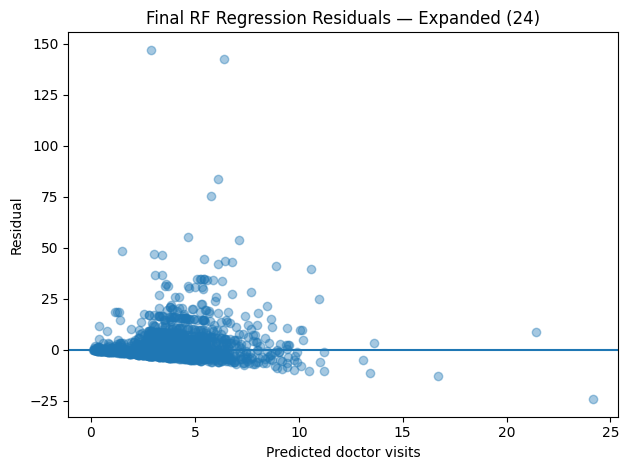

In [26]:
residuals = y_test_reg - final_reg_pred
plt.scatter(final_reg_pred, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel('Predicted doctor visits')
plt.ylabel('Residual')
plt.title(f'Final RF Regression Residuals — {final_reg_feature_set}')
plt.tight_layout()
plt.show()

# Subgroup performance

The agreed subgroup dimensions are retained: race/ethnicity, poverty, insurance, and urban/rural. Subgroup results use the **CV-selected final model**, not a model selected from test performance.

In [27]:
race_labels = {
    1: 'Latino', 2: 'Other single/multiple race',
    3: 'American Indian/Alaska Native', 4: 'Asian',
    5: 'African American', 6: 'White'
}
poverty_labels = {
    1: '0-99% FPL', 2: '100-199% FPL',
    3: '200-299% FPL', 4: '300% FPL and above'
}
insurance_labels = {
    1: 'Uninsured', 2: 'Medicare & Medicaid',
    3: 'Medicare & others', 4: 'Medicare only',
    5: 'Medicaid', 7: 'Employment-based',
    8: 'Privately purchased', 9: 'Other public'
}
region_labels = {1: 'Urban', 2: 'Mixed', 3: 'Suburban', 4: 'Rural'}

subgroups = {
    'Race/ethnicity': ('racehp2_p1', race_labels),
    'Poverty level': ('povll', poverty_labels),
    'Insurance type': ('instype', insurance_labels),
    'Urban/rural': ('ur_clrt4', region_labels)
}

In [28]:
def classification_by_group(col, labels):
    rows = []
    for value in sorted(test[col].dropna().unique()):
        mask = test[col] == value
        yg = y_test[mask]
        pg = final_class_pred[mask]
        prg = final_class_prob[mask]
        rows.append({
            'Group': labels.get(value, value),
            'n': len(yg),
            'Precision': precision_score(yg, pg, zero_division=0),
            'Recall': recall_score(yg, pg, zero_division=0),
            'F1': f1_score(yg, pg, zero_division=0),
            'ROC-AUC': roc_auc_score(yg, prg) if yg.nunique() == 2 else np.nan,
            'PR-AUC': average_precision_score(yg, prg) if yg.nunique() == 2 else np.nan
        })
    return pd.DataFrame(rows)

classification_group_results = {}
for name, (col, labels) in subgroups.items():
    if col in test.columns:
        classification_group_results[name] = classification_by_group(col, labels)
        print(name)
        display(classification_group_results[name].round(3))

Race/ethnicity


,Group,n,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Latino,342,0.476,0.348,0.402,0.650,0.428
1,Other single/multiple race,325,0.547,0.337,0.417,0.682,0.501
2,American Indian/Alaska Native,43,0.400,0.125,0.190,0.579,0.465
3,Asian,341,0.455,0.205,0.283,0.700,0.424
4,African American,151,0.667,0.311,0.424,0.729,0.537
5,White,1138,0.481,0.183,0.266,0.704,0.431


Poverty level


,Group,n,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0-99% FPL,300,0.500,0.439,0.468,0.671,0.491
1,100-199% FPL,358,0.529,0.357,0.426,0.690,0.537
2,200-299% FPL,278,0.542,0.333,0.413,0.746,0.506
3,300% FPL and above,1404,0.451,0.118,0.187,0.669,0.354


Insurance type


,Group,n,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Uninsured,66,0.536,0.714,0.612,0.769,0.583
1,Medicare & Medicaid,203,0.561,0.386,0.457,0.679,0.546
2,Medicare & others,735,0.385,0.070,0.119,0.680,0.326
3,Medicare only,85,0.500,0.222,0.308,0.667,0.380
4,Medicaid,261,0.538,0.433,0.480,0.697,0.563
5,Employment-based,881,0.459,0.189,0.268,0.674,0.403
6,Privately purchased,84,0.467,0.280,0.350,0.652,0.424
7,Other public,25,1.000,0.250,0.400,0.607,0.410


Urban/rural


,Group,n,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Urban,922,0.478,0.266,0.342,0.682,0.408
1,Mixed,248,0.588,0.349,0.438,0.742,0.579
2,Suburban,751,0.386,0.155,0.221,0.678,0.379
3,Rural,419,0.630,0.274,0.382,0.723,0.532


In [29]:
lines = ["### Classification subgroup interpretation"]
small = []
for name, result in classification_group_results.items():
    best = result.loc[result['F1'].idxmax()]
    worst = result.loc[result['F1'].idxmin()]
    lines.append(
        f"- **{name}:** highest F1 = **{best['Group']} ({best['F1']:.3f})**; "
        f"lowest F1 = **{worst['Group']} ({worst['F1']:.3f})**."
    )
    small += [
        f"{name}: {row['Group']} (n={int(row['n'])})"
        for _, row in result.iterrows() if row['n'] < 50
    ]
if small:
    lines.append("\nVery small groups should be interpreted cautiously: " + "; ".join(small) + ".")
else:
    lines.append("\nThese are descriptive performance differences; smaller groups remain less stable.")
display(Markdown("\n".join(lines)))

### Classification subgroup interpretation
- **Race/ethnicity:** highest F1 = **African American (0.424)**; lowest F1 = **American Indian/Alaska Native (0.190)**.
- **Poverty level:** highest F1 = **0-99% FPL (0.468)**; lowest F1 = **300% FPL and above (0.187)**.
- **Insurance type:** highest F1 = **Uninsured (0.612)**; lowest F1 = **Medicare & others (0.119)**.
- **Urban/rural:** highest F1 = **Mixed (0.438)**; lowest F1 = **Suburban (0.221)**.

Very small groups should be interpreted cautiously: Race/ethnicity: American Indian/Alaska Native (n=43); Insurance type: Other public (n=25).

In [30]:
def regression_by_group(col, labels):
    rows = []
    for value in sorted(test[col].dropna().unique()):
        mask = test[col] == value
        yg = y_test_reg[mask]
        pg = final_reg_pred[mask]
        rows.append({
            'Group': labels.get(value, value),
            'n': len(yg),
            'MAE': mean_absolute_error(yg, pg),
            'RMSE': np.sqrt(mean_squared_error(yg, pg)),
            'R²': r2_score(yg, pg) if len(yg) >= 2 else np.nan
        })
    return pd.DataFrame(rows)

regression_group_results = {}
for name, (col, labels) in subgroups.items():
    if col in test.columns:
        regression_group_results[name] = regression_by_group(col, labels)
        print(name)
        display(regression_group_results[name].round(3))

Race/ethnicity


,Group,n,MAE,RMSE,R²
0,Latino,342,4.159,12.792,0.011
1,Other single/multiple race,325,2.817,4.734,0.093
2,American Indian/Alaska Native,43,2.504,3.192,-0.000
3,Asian,341,2.737,5.665,0.031
4,African American,151,3.904,7.279,0.016
5,White,1138,3.986,7.825,0.016


Poverty level


,Group,n,MAE,RMSE,R²
0,0-99% FPL,300,4.375,8.893,0.038
1,100-199% FPL,358,4.753,12.785,-0.015
2,200-299% FPL,278,3.015,5.555,0.005
3,300% FPL and above,1404,3.314,6.618,0.053


Insurance type


,Group,n,MAE,RMSE,R²
0,Uninsured,66,1.587,3.167,0.108
1,Medicare & Medicaid,203,5.628,13.936,-0.028
2,Medicare & others,735,3.880,7.634,0.012
3,Medicare only,85,4.040,7.956,0.023
4,Medicaid,261,3.919,10.856,0.015
5,Employment-based,881,3.005,5.504,0.018
6,Privately purchased,84,3.509,7.339,0.086
7,Other public,25,3.870,8.996,0.076


Urban/rural


,Group,n,MAE,RMSE,R²
0,Urban,922,3.684,8.560,0.038
1,Mixed,248,3.677,6.627,0.061
2,Suburban,751,3.500,6.716,-0.003
3,Rural,419,3.741,9.767,0.029


In [31]:
lines = ["### Regression subgroup interpretation"]
small = []
for name, result in regression_group_results.items():
    best = result.loc[result['MAE'].idxmin()]
    worst = result.loc[result['MAE'].idxmax()]
    lines.append(
        f"- **{name}:** lowest MAE = **{best['Group']} ({best['MAE']:.3f})**; "
        f"highest MAE = **{worst['Group']} ({worst['MAE']:.3f})**."
    )
    small += [
        f"{name}: {row['Group']} (n={int(row['n'])})"
        for _, row in result.iterrows() if row['n'] < 50
    ]
if small:
    lines.append("\nVery small groups should be interpreted cautiously: " + "; ".join(small) + ".")
else:
    lines.append("\nThese are descriptive performance differences; smaller groups remain less stable.")
display(Markdown("\n".join(lines)))

### Regression subgroup interpretation
- **Race/ethnicity:** lowest MAE = **American Indian/Alaska Native (2.504)**; highest MAE = **Latino (4.159)**.
- **Poverty level:** lowest MAE = **200-299% FPL (3.015)**; highest MAE = **100-199% FPL (4.753)**.
- **Insurance type:** lowest MAE = **Uninsured (1.587)**; highest MAE = **Medicare & Medicaid (5.628)**.
- **Urban/rural:** lowest MAE = **Suburban (3.500)**; highest MAE = **Rural (3.741)**.

Very small groups should be interpreted cautiously: Race/ethnicity: American Indian/Alaska Native (n=43); Insurance type: Other public (n=25).

## Bootstrap subgroup uncertainty

500 bootstrap samples are used for classification recall/F1 and regression MAE confidence intervals.

In [32]:
def bootstrap_classification(col, labels, n_boot=500):
    rng = np.random.default_rng(42)
    values = test[col].to_numpy()
    rows = []
    for value in sorted(test[col].dropna().unique()):
        idx = np.where(values == value)[0]
        recalls, f1s = [], []
        for _ in range(n_boot):
            s = rng.choice(idx, size=len(idx), replace=True)
            yg = y_test.iloc[s]
            pg = final_class_pred[s]
            recalls.append(recall_score(yg, pg, zero_division=0))
            f1s.append(f1_score(yg, pg, zero_division=0))
        rows.append({
            'Group': labels.get(value, value), 'n': len(idx),
            'Recall': np.mean(recalls), 'Recall Low': np.percentile(recalls, 2.5),
            'Recall High': np.percentile(recalls, 97.5),
            'F1': np.mean(f1s), 'F1 Low': np.percentile(f1s, 2.5),
            'F1 High': np.percentile(f1s, 97.5)
        })
    return pd.DataFrame(rows)

def bootstrap_regression(col, labels, n_boot=500):
    rng = np.random.default_rng(42)
    values = test[col].to_numpy()
    rows = []
    for value in sorted(test[col].dropna().unique()):
        idx = np.where(values == value)[0]
        maes = []
        for _ in range(n_boot):
            s = rng.choice(idx, size=len(idx), replace=True)
            maes.append(mean_absolute_error(y_test_reg.iloc[s], final_reg_pred[s]))
        rows.append({
            'Group': labels.get(value, value), 'n': len(idx),
            'MAE': np.mean(maes), 'MAE Low': np.percentile(maes, 2.5),
            'MAE High': np.percentile(maes, 97.5)
        })
    return pd.DataFrame(rows)

classification_bootstrap_results = {}
regression_bootstrap_results = {}
for name, (col, labels) in subgroups.items():
    if col in test.columns:
        classification_bootstrap_results[name] = bootstrap_classification(col, labels)
        regression_bootstrap_results[name] = bootstrap_regression(col, labels)
        print(name, "- Classification")
        display(classification_bootstrap_results[name].round(3))
        print(name, "- Regression")
        display(regression_bootstrap_results[name].round(3))

Race/ethnicity - Classification


,Group,n,Recall,Recall Low,Recall High,F1,F1 Low,F1 High
0,Latino,342,0.351,0.263,0.444,0.404,0.323,0.488
1,Other single/multiple race,325,0.337,0.243,0.437,0.417,0.320,0.510
2,American Indian/Alaska Native,43,0.131,0.000,0.326,0.191,0.000,0.436
3,Asian,341,0.199,0.113,0.294,0.274,0.167,0.382
4,African American,151,0.316,0.190,0.457,0.425,0.283,0.565
5,White,1138,0.183,0.139,0.228,0.264,0.206,0.322


Race/ethnicity - Regression


,Group,n,MAE,MAE Low,MAE High
0,Latino,342,4.202,3.060,5.657
1,Other single/multiple race,325,2.805,2.436,3.240
2,American Indian/Alaska Native,43,2.496,1.935,3.102
3,Asian,341,2.718,2.257,3.248
4,African American,151,3.881,2.977,4.812
5,White,1138,3.970,3.624,4.349


Poverty level - Classification


...

,Group,n,MAE,MAE Low,MAE High
0,Uninsured,66,1.627,1.057,2.494
1,Medicare & Medicaid,203,5.581,4.205,7.352
2,Medicare & others,735,3.893,3.446,4.424
3,Medicare only,85,4.068,2.827,5.757
4,Medicaid,261,3.927,2.959,5.415
5,Employment-based,881,3.001,2.672,3.281
6,Privately purchased,84,3.474,2.278,4.936
7,Other public,25,3.817,1.608,7.528


Urban/rural - Classification


,Group,n,Recall,Recall Low,Recall High,F1,F1 Low,F1 High
0,Urban,922,0.266,0.207,0.321,0.342,0.275,0.403
1,Mixed,248,0.344,0.250,0.451,0.432,0.323,0.536
2,Suburban,751,0.157,0.106,0.214,0.223,0.160,0.290
3,Rural,419,0.272,0.195,0.355,0.379,0.291,0.465


Urban/rural - Regression


,Group,n,MAE,MAE Low,MAE High
0,Urban,922,3.664,3.173,4.158
1,Mixed,248,3.654,3.013,4.350
2,Suburban,751,3.499,3.097,3.917
3,Rural,419,3.761,3.000,4.671


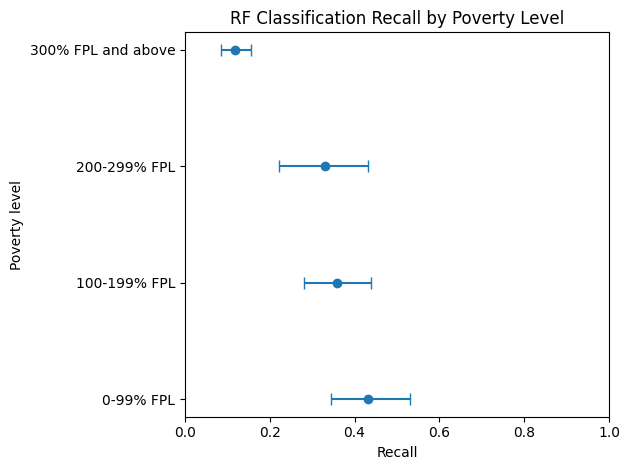

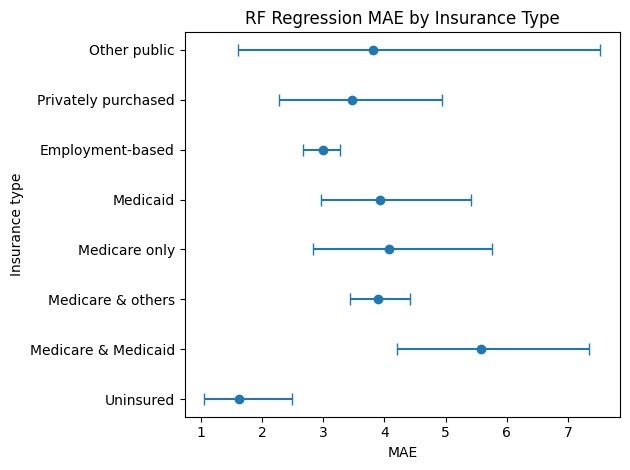

In [33]:
if 'Poverty level' in classification_bootstrap_results:
    r = classification_bootstrap_results['Poverty level']
    x = r['Recall']
    plt.errorbar(
        x, r['Group'],
        xerr=[x - r['Recall Low'], r['Recall High'] - x],
        fmt='o', capsize=4
    )
    plt.xlabel('Recall')
    plt.ylabel('Poverty level')
    plt.title('RF Classification Recall by Poverty Level')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

if 'Insurance type' in regression_bootstrap_results:
    r = regression_bootstrap_results['Insurance type']
    x = r['MAE']
    plt.errorbar(
        x, r['Group'],
        xerr=[x - r['MAE Low'], r['MAE High'] - x],
        fmt='o', capsize=4
    )
    plt.xlabel('MAE')
    plt.ylabel('Insurance type')
    plt.title('RF Regression MAE by Insurance Type')
    plt.tight_layout()
    plt.show()

# Permutation importance

Permutation importance is calculated for the **CV-selected final models**. If the expanded model wins CV, the 7 insurance/access variables are included automatically.

- Classification: decrease in F1 after shuffling
- Regression: increase in MAE after shuffling

Interpretation is predictive, not causal.

,Predictor,Importance,SD
4,sreduc,0.035,0.008
11,diabetes,0.027,0.014
10,ab17,0.027,0.013
15,povll2_p1v2,0.021,0.012
17,instype,0.015,0.006
19,usual,0.013,0.004
7,ab1,0.008,0.008
16,bmi_p,0.008,0.009
18,coverage_continuity,0.005,0.003
21,ah22,0.004,0.004


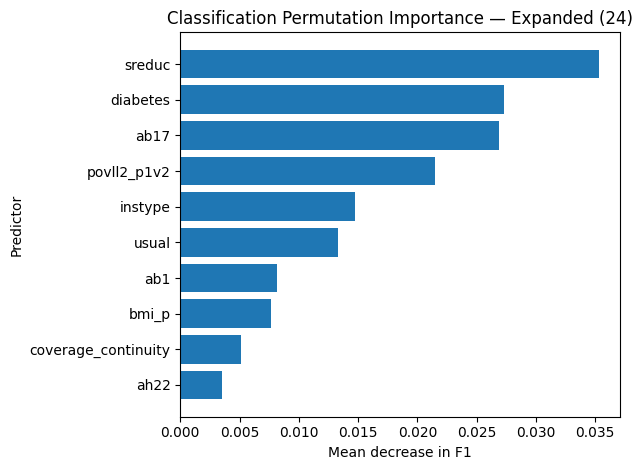

In [34]:
final_class_predictors = base_predictors if final_class_feature_set == 'Base (17)' else expanded_predictors
final_class_X_test = X_test_sets[final_class_feature_set]

class_perm = permutation_importance(
    final_classifier, final_class_X_test, y_test,
    scoring=make_scorer(f1_score, zero_division=0),
    n_repeats=20, random_state=42, n_jobs=-1
)

class_importance_df = pd.DataFrame({
    'Predictor': final_class_predictors,
    'Importance': class_perm.importances_mean,
    'SD': class_perm.importances_std
}).sort_values('Importance', ascending=False)

display(class_importance_df.round(3))

top = class_importance_df.head(10).sort_values('Importance')
plt.barh(top['Predictor'], top['Importance'])
plt.xlabel('Mean decrease in F1')
plt.ylabel('Predictor')
plt.title(f'Classification Permutation Importance — {final_class_feature_set}')
plt.tight_layout()
plt.show()

In [35]:
top3 = class_importance_df.head(3)['Predictor'].tolist()
display(Markdown(
    "### Classification importance interpretation\n\n"
    "The three strongest predictors by permutation importance are **"
    + "**, **".join(top3)
    + "**. Shuffling them causes the largest decreases in held-out F1. "
      "This indicates predictive reliance, not causation."
))

### Classification importance interpretation

The three strongest predictors by permutation importance are **sreduc**, **diabetes**, **ab17**. Shuffling them causes the largest decreases in held-out F1. This indicates predictive reliance, not causation.

,Predictor,Importance,SD
7,ab1,0.154,0.017
23,aj218,0.119,0.012
13,ab34,0.070,0.011
2,racehp2_p1,0.046,0.010
19,usual,0.033,0.009
0,srage_p1,0.023,0.008
1,srsex,0.021,0.005
20,ah81b,0.016,0.009
5,wrkst_p1,0.013,0.007
15,povll2_p1v2,0.009,0.007


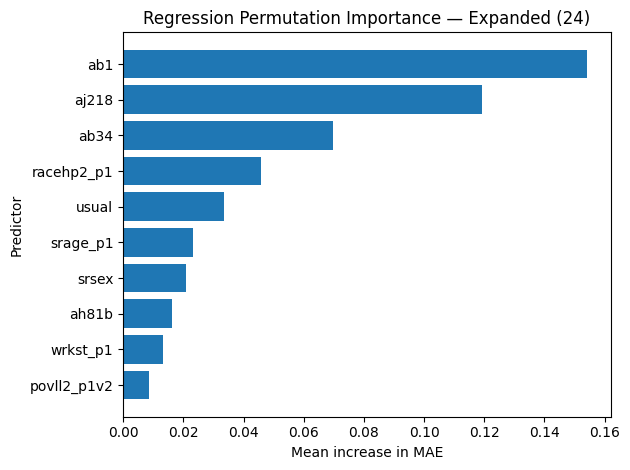

In [36]:
final_reg_predictors = base_predictors if final_reg_feature_set == 'Base (17)' else expanded_predictors
final_reg_X_test = X_test_sets[final_reg_feature_set]

def neg_mae_original_scale(estimator, X, y):
    pred = estimator.predict(X)
    if selected_reg_target == 'log1p':
        pred = np.expm1(pred)
    pred = np.clip(pred, 0, None)
    return -mean_absolute_error(y, pred)

reg_perm = permutation_importance(
    final_regressor, final_reg_X_test, y_test_reg,
    scoring=neg_mae_original_scale,
    n_repeats=20, random_state=42, n_jobs=-1
)

reg_importance_df = pd.DataFrame({
    'Predictor': final_reg_predictors,
    'Importance': reg_perm.importances_mean,
    'SD': reg_perm.importances_std
}).sort_values('Importance', ascending=False)

display(reg_importance_df.round(3))

top = reg_importance_df.head(10).sort_values('Importance')
plt.barh(top['Predictor'], top['Importance'])
plt.xlabel('Mean increase in MAE')
plt.ylabel('Predictor')
plt.title(f'Regression Permutation Importance — {final_reg_feature_set}')
plt.tight_layout()
plt.show()

In [37]:
top3 = reg_importance_df.head(3)['Predictor'].tolist()
final_r2 = regression_test_table.loc[
    f'Tuned RF — {final_reg_feature_set} — {tuned_target_label}', 'R²'
]
display(Markdown(
    "### Regression importance interpretation\n\n"
    "The three strongest predictors by permutation importance are **"
    + "**, **".join(top3)
    + f"**. The final held-out test R² is **{final_r2:.3f}**. "
      "If R² remains close to zero, the model still explains very little of the "
      "variation in doctor visits even when MAE/RMSE improve. "
      "Permutation importance is predictive, not causal."
))

### Regression importance interpretation

The three strongest predictors by permutation importance are **ab1**, **aj218**, **ab34**. The final held-out test R² is **0.029**. If R² remains close to zero, the model still explains very little of the variation in doctor visits even when MAE/RMSE improve. Permutation importance is predictive, not causal.

# Final Random Forest summary

Use the newly executed values from this notebook for the final project. Do **not** reuse results from the older 20-predictor RF run.

In [38]:
print("CLASSIFICATION — HELD-OUT TEST")
display(classification_test_table.round(3))
print("CV-selected classifier feature set:", final_class_feature_set)
print("Selected classifier parameters:", best_class_params[final_class_feature_set])
print()

print("REGRESSION — HELD-OUT TEST")
display(regression_test_table.round(3))
print("CV-selected regressor feature set:", final_reg_feature_set)
print("CV-selected target:", selected_reg_target_label)
print("Selected regressor parameters:", best_reg_params[final_reg_feature_set])

CLASSIFICATION — HELD-OUT TEST


,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline RF — Base (17),0.525,0.215,0.305,0.691,0.435
Tuned RF — Base (17),0.524,0.261,0.349,0.695,0.443
Baseline RF — Expanded (24),0.512,0.199,0.287,0.693,0.438
Tuned RF — Expanded (24),0.502,0.248,0.332,0.699,0.441


CV-selected classifier feature set: Expanded (24)
Selected classifier parameters: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.5, 'class_weight': None}

REGRESSION — HELD-OUT TEST


,MAE,RMSE,R²
Baseline RF — Base (17) — AH5,4.749,9.065,-0.226
Tuned RF — Base (17) — log1p(AH5),3.751,8.131,0.014
Baseline RF — Expanded (24) — AH5,4.563,8.580,-0.098
Tuned RF — Expanded (24) — log1p(AH5),3.634,8.068,0.029


CV-selected regressor feature set: Expanded (24)
CV-selected target: log1p(AH5)
Selected regressor parameters: {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 1.0}
